<div style="background-color:black; color:white; padding:40px; text-align:left;">

<span style="font-size:32px; font-weight:bold;">
Examen - Primer Parcial
</span>  

Nombre: Emily Junny Leniz Coa  
Materia: INF672 - Machine Learning  
Fecha: 16/09/2026  

</div>



In [7]:
# Ejercicio 1
import itertools
import numpy as np
import pandas as pd

pares_posibles = list(itertools.product(range(1, 7), repeat=2))
favorables = sum(1 for a, b in pares_posibles if a == 6 or b == 6)
prob_exacta = favorables / len(pares_posibles)

rng = np.random.default_rng(42)

N_valores = [100, 1000, 100000]
estimaciones = []
errores = []

for N in N_valores:
    tiradas = rng.integers(1, 7, size=(N, 2))
    al_menos_un_seis = np.any(tiradas == 6, axis=1)
    prob_est = np.mean(al_menos_un_seis)
    error = abs(prob_est - prob_exacta)
    
    estimaciones.append(prob_est)
    errores.append(error)

df_e1 = pd.DataFrame({
    'N (Tiradas)': N_valores,
    'Probabilidad Estimada': estimaciones,
    'Valor Exacto': [prob_exacta] * 3,
    'Error Absoluto': errores
})

print(f"Valor Exacto: {prob_exacta:.6f} ({favorables}/{len(pares_posibles)})")
display(df_e1)

Valor Exacto: 0.305556 (11/36)


,N (Tiradas),Probabilidad Estimada,Valor Exacto,Error Absoluto
0,100,0.24000,0.305556,0.065556
1,1000,0.31000,0.305556,0.004444
2,100000,0.30583,0.305556,0.000274


**Respuesta** <br> El valor exacto es $11/36 = 0.305556$. <br>  **¿Cuál se acercó más y por qué?** <br> **R.** La estimación con $N = 100\,000$ es la más cercana al valor exacto, esto sucede debido a la Ley de los grandes números, la cual establece que a medida que aumenta el número de repeticiones de un experimento aleatorio, la frecuencia de un evento converge a su probabilidad teórica real. <br> **¿Qué le pasa a la estimación cuando tienes pocas tiradas?** <br> **R.** Cuando hay pocas tiradas $N = 100$, la estimación presenta una alta varianza, los resultados dependen del azar de la muestra seleccionada, lo que produce un margen de error respecto al valor teórico.  

In [8]:
# Ejercicio 2
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

df_iris = sns.load_dataset('iris')

def q1(x): return x.quantile(0.25)
def q2(x): return x.quantile(0.50)
def q3(x): return x.quantile(0.75)

perfil = df_iris.groupby('species').agg(['mean', 'median', 'std', q1, q2, q3])
print("Perfil Estadístico por Especie:")
display(perfil)

np.random.seed(42)
df_iris_nan = df_iris.copy()
for col in df_iris.columns[:-1]:
    idx = np.random.choice(df_iris_nan.index, size=5, replace=False)
    df_iris_nan.loc[idx, col] = np.nan

print("Conteo de faltantes introducidos:")
print(df_iris_nan.isna().sum())

for col in df_iris_nan.columns[:-1]:
    df_iris_nan[col] = df_iris_nan.groupby('species')[col].transform(lambda x: x.fillna(x.median()))

print("Conteo de faltantes tras imputación:")
print(df_iris_nan.isna().sum())

medias_por_especie = df_iris.groupby('species').mean()
print("Medias por especie:")
display(medias_por_especie)

Perfil Estadístico por Especie:


sepal_length                                   sepal_width                                     petal_length                                    petal_width                                
                   mean median       std     q1   q2   q3        mean median       std     q1   q2     q3         mean median       std   q1    q2     q3        mean median       std   q1   q2   q3
species                                                                                                                                                                                              
setosa            5.006    5.0  0.352490  4.800  5.0  5.2       3.428    3.4  0.379064  3.200  3.4  3.675        1.462   1.50  0.173664  1.4  1.50  1.575       0.246    0.2  0.105386  0.2  0.2  0.3
versicolor        5.936    5.9  0.516171  5.600  5.9  6.3       2.770    2.8  0.313798  2.525  2.8  3.000        4.260   4.35  0.469911  4.0  4.35  4.600       1.326    1.3  0.197753  1.2  1.3  1.5
virginica         6.588    6.5  0.635880  6.225  6.5  6.9       2.974    3.0  0.322497  2.800  3.0  3.175        5.552   5.55  0.551895  5.1  5.55  5.875       2.026    2.0  0.274650  1.8  2.0  2.3

Conteo de faltantes introducidos:
sepal_length    5
sepal_width     5
petal_length    5
petal_width     5
species         0
dtype: int64
Conteo de faltantes tras imputación:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64
Medias por especie:


,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


**Respuesta** <br> **¿Por qué una característica con medias muy distintas entre especies separa mejor que una con medias parecidas?** <br> **R.** Una mayor distancia entre las medias disminuye el solapamiento de datos entre grupos, lo que facilita definir fronteras de decisión claras para clasificar correctamente.

In [9]:
# Ejercicio 3
import numpy as np
import pandas as pd
import seaborn as sns

df_iris = sns.load_dataset('iris')

def distancia_euclidiana(a, b):
    return np.sqrt(np.sum((a - b)**2))

def producto_punto(a, b):
    return np.sum(a * b)

def similitud_coseno(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

idx_setosa1 = 0
idx_setosa2 = 1
idx_versicolor1 = 50
idx_virginica1 = 100

v_set1 = df_iris.iloc[idx_setosa1, :-1].to_numpy(dtype=float)
v_set2 = df_iris.iloc[idx_setosa2, :-1].to_numpy(dtype=float)
v_ver1 = df_iris.iloc[idx_versicolor1, :-1].to_numpy(dtype=float)
v_vir1 = df_iris.iloc[idx_virginica1, :-1].to_numpy(dtype=float)

pares = [
    (f"Misma especie (Setosa {idx_setosa1} - Setosa {idx_setosa2})", v_set1, v_set2),
    (f"Distinta especie (Setosa {idx_setosa1} - Versicolor {idx_versicolor1})", v_set1, v_ver1),
    (f"Distinta especie (Setosa {idx_setosa1} - Virginica {idx_virginica1})", v_set1, v_vir1),
    (f"Distinta especie (Versicolor {idx_versicolor1} - Virginica {idx_virginica1})", v_ver1, v_vir1)
]

resultados = []
for nombre, a, b in pares:
    d_euc = distancia_euclidiana(a, b)
    p_punto = producto_punto(a, b)
    s_cos = similitud_coseno(a, b)
    resultados.append({
        'Par de Flores': nombre,
        'Distancia Euclidiana': d_euc,
        'Producto Punto': p_punto,
        'Similitud Coseno': s_cos
    })

df_e3 = pd.DataFrame(resultados)
display(df_e3)

,Par de Flores,Distancia Euclidiana,Producto Punto,Similitud Coseno
0,Misma especie (Setosa 0 - Setosa 1),0.538516,37.49,0.998579
1,Distinta especie (Setosa 0 - Versicolor 50),4.003748,53.76,0.928380
2,Distinta especie (Setosa 0 - Virginica 100),5.284884,52.58,0.860081
3,Distinta especie (Versicolor 50 - Virginica 100),1.843909,86.36,0.982137


**Respuestas** <br> 
**¿Las flores de la misma especie salieron "más parecidas"?** <br> **R.** Sí. Las flores de la misma especie (Setosa - Setosa) muestran la menor distancia euclidiana y la mayor similitud coseno (cercana a 1), confirmando que son más semejantes entre sí que con flores de especies distintas. <br> **¿La distancia euclidiana y la similitud coseno ordenan las flores igual?** <br> **R.** No necesariamente, la distancia euclidiana evalúa la diferencia de magnitud absoluta en el espacio métrico, mientras que la similitud coseno mide únicamente el ángulo entre vectores ignorando sus magnitudes.

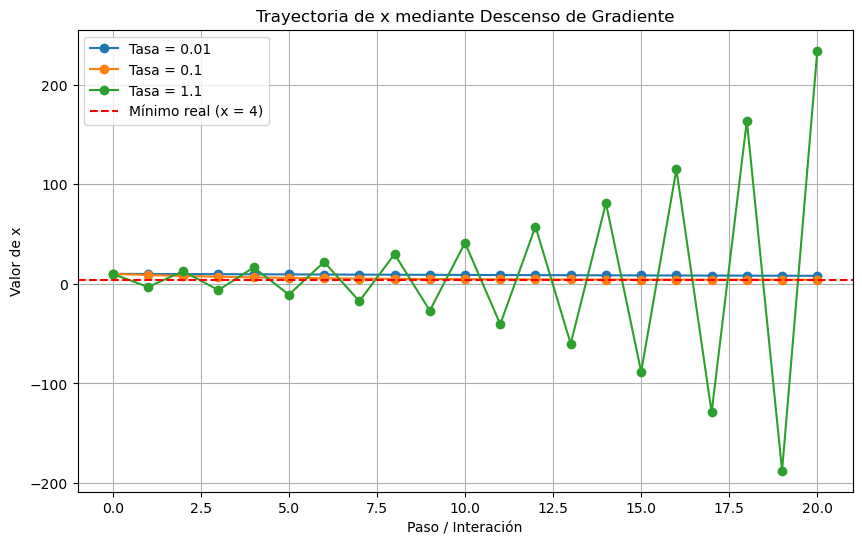

,Tasa de Aprendizaje,x Final (Paso 20),Mínimo Real,Error Absoluto Final
0,0.01,8.005648,4.0,4.005648
1,0.10,4.069175,4.0,0.069175
2,1.10,234.025600,4.0,230.025600


In [10]:
# Ejercicio 4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def f(x):
    return (x - 4)**2 + 1

def df(x):
    return 2 * (x - 4)

tasas = [0.01, 0.1, 1.1]
pasos = 20
x_inicial = 10.0

trayectorias = {}

for lr in tasas:
    x_hist = [x_inicial]
    x_actual = x_inicial
    for _ in range(pasos):
        gradiente = df(x_actual)
        x_actual = x_actual - lr * gradiente
        x_hist.append(x_actual)
    trayectorias[lr] = x_hist

plt.figure(figsize=(10, 6))
for lr, hist in trayectorias.items():
    plt.plot(range(len(hist)), hist, marker='o', label=f'Tasa = {lr}')

plt.axhline(4, color='red', linestyle='--', label='Mínimo real (x = 4)')
plt.xlabel('Paso / Interación')
plt.ylabel('Valor de x')
plt.title('Trayectoria de x mediante Descenso de Gradiente')
plt.legend()
plt.grid(True)
plt.show()

df_e4 = pd.DataFrame({
    'Tasa de Aprendizaje': tasas,
    'x Final (Paso 20)': [trayectorias[lr][-1] for lr in tasas],
    'Mínimo Real': [4.0] * len(tasas),
    'Error Absoluto Final': [abs(trayectorias[lr][-1] - 4.0) for lr in tasas]
})
display(df_e4)

**Respuestas** <br> **¿Todas llegan cerca del mínimo?** <br> **R.** No, solo las tasas de $0.01$ y $0.1$ logran acercarse al mínimo $x = 4$. <br>  **¿Qué pasa con la tasa muy pequeña ($0.01$)** <br> **R.** Avanza muy despacio ya que necesita muchos pasos para llegar al valor correcto porque los cambios en $x$ son muy pequeños. <br> **¿Qué pasa con la tasa intermedia ($0.1$)** <br> **R.** Llega de forma rápida y estable al valor mínimo $x = 4$. <br> **¿Qué pasa con la tasa muy grande ($1.1$)** <br> **R.** Al ser un paso tan grande, se pasa del mínimo, rebota de un lado a otro y $x$ se dispara cada vez más lejos del objetivo. 